# DATA09 特征重要性排序与 6:4 测试验证

本 notebook 用于分析已经计算完成的 DATA09 特征 CSV。特征来源为 `DATA09_single_event_feature_extract.ipynb` 和 `DATA09_v0-flow_feature_extraction.ipynb`，本程序不重新计算原始信号特征，只负责合并、划分、重要性排序、模型测试和可视化。

核心设计：

- 合并：读取多个 CSV，自动去除重复输入文件，并取多文件共有的数值特征列。
- 划分：先按 6:4 比例划分数据，其中 60% 用于训练、调参与特征重要性排序，40% 作为独立测试集。
- 建模：使用带 median imputer 的 RandomForest pipeline，避免缺失值处理泄漏到测试集。
- 排序：主排序使用训练集内分组交叉验证 permutation importance，并辅以 RandomForest impurity importance 的多随机种子稳定性；测试集 permutation importance 仅作为独立测试审计，不参与主排序。
- 输出：保存合并表、划分表、测试指标、特征质量表、特征重要性表和可视化图。


## 1. 环境初始化

导入依赖、设置绘图风格、定位项目根目录，并为本次分析创建带时间戳的输出目录。


In [1]:
from __future__ import annotations

from datetime import datetime
from pathlib import Path
import json
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import GroupShuffleSplit, StratifiedGroupKFold, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=pd.errors.PerformanceWarning)

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except Exception:
    pass

plt.rcParams.update({
    'figure.dpi': 120,
    'savefig.dpi': 180,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
})

workspace = Path.cwd()
if not (workspace / 'outputs').exists() and (workspace.parent / 'outputs').exists():
    workspace = workspace.parent

RUN_TIMESTAMP = datetime.now().strftime('%Y%m%d_%H%M%S')
OUTPUT_ROOT = workspace / 'outputs' / f'DATA09_feature_importance_from_csv_{RUN_TIMESTAMP}'
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

print(f'workspace: {workspace}')
print(f'RUN_TIMESTAMP: {RUN_TIMESTAMP}')
print(f'OUTPUT_ROOT: {OUTPUT_ROOT}')


workspace: e:\codes\ZZ-BK
RUN_TIMESTAMP: 20260906_002442
OUTPUT_ROOT: e:\codes\ZZ-BK\outputs\DATA09_feature_importance_from_csv_20260906_002442


## 2. 输入配置

在 `FEATURE_FILES` 中填写已经计算好的特征 CSV。程序会自动跳过重复路径，并固定使用 6:4 划分，40% 数据作为测试集。


In [2]:
# =========================
# Input configuration
# =========================

FEATURE_FILES = [
    Path(r'E:\codes\ZZ-BK\outputs\DATA09_v0-qj_features_QJ\features_QJ_20260904_114606.csv'),
    Path(r'E:\codes\ZZ-BK\outputs\DATA09_v0-flow_features_20260904_121425\features_20260904_121425_part_0001.csv'),
    Path(r'E:\codes\ZZ-BK\outputs\DATA09_v0-flow_features_20260904_121425\features_20260904_121425_part_0001.csv'),
]

LABEL_BY_PATH_KEYWORD = {
    'v0-flow': 'flow',
    'flow': 'flow',
    'BK00': 'BK00',
    'v0-bk': 'BK00',
    'bk': 'BK00',
    'QJ': 'QJ',
    'v0-qj': 'QJ',
    'qj': 'QJ',
}

RANDOM_STATE = 42
TEST_SIZE = 0.40
TOP_N = 30
N_ESTIMATORS = 500
RUN_PERMUTATION_IMPORTANCE = True
PERMUTATION_REPEATS = 5
CV_FOLDS = 5
RF_STABILITY_SEEDS = [11, 23, 37, 41, 53]
CORRELATION_THRESHOLD = 0.95
NEAR_ZERO_STD_THRESHOLD = 1e-12

print(f'Train ratio target: {1 - TEST_SIZE:.0%}')
print(f'Test ratio target:  {TEST_SIZE:.0%}')
print('Configured FEATURE_FILES:')
for p in FEATURE_FILES:
    print(' ', p)


Train ratio target: 60%
Test ratio target:  40%
Configured FEATURE_FILES:
  E:\codes\ZZ-BK\outputs\DATA09_v0-qj_features_QJ\features_QJ_20260904_114606.csv
  E:\codes\ZZ-BK\outputs\DATA09_v0-flow_features_20260904_121425\features_20260904_121425_part_0001.csv
  E:\codes\ZZ-BK\outputs\DATA09_v0-flow_features_20260904_121425\features_20260904_121425_part_0001.csv


## 3. 工具函数

定义标签识别、CSV 加载、共同数值特征筛选和源文件分组划分等辅助函数。


In [3]:
# =========================
# Helper functions
# =========================

META_COLUMNS = {
    'source_file_name', 'source_file_path', 'source_format',
    'source_group_name', 'source_channel_name', 'source_detail',
    'label', 'sample_type', 'window_mode',
    'window_id', 'window_start_index', 'window_end_index',
    'window_length_samples', 'window_step_samples', 'window_duration_s', 'window_start_offset_s',
    'window_start_datetime', 'window_start_ms', 'window_end_ms', 'window_n_samples',
    'sample_rate_hz', 'original_sample_rate_hz', 'source_n_samples', 'source_duration_s',
    'starttime_raw', 'arrival_time_raw', 'arrival_time', 'starttime', 'channel_index',
}


def infer_label_from_path(path: Path) -> str:
    text = str(path).lower()
    for key, label in LABEL_BY_PATH_KEYWORD.items():
        if key.lower() in text:
            return label
    return path.parent.name


def normalize_label_value(value: object, path: Path) -> str:
    if pd.isna(value) or str(value).strip() == '':
        return infer_label_from_path(path)
    text = str(value).strip()
    lower = text.lower()
    if lower in {'v0-flow', 'flow'}:
        return 'flow'
    if lower in {'bk', 'bk00', 'v0-bk'}:
        return 'BK00'
    if lower in {'qj', 'v0-qj'}:
        return 'QJ'
    return text


def load_one_feature_csv(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(path)
    df = pd.read_csv(path)
    df['feature_csv_path'] = str(path)
    df['feature_csv_name'] = path.name
    if 'label' in df.columns:
        raw_label = df['label']
    elif 'sample_type' in df.columns:
        raw_label = df['sample_type']
    else:
        raw_label = pd.Series([infer_label_from_path(path)] * len(df), index=df.index)
    df['label'] = [normalize_label_value(v, path) for v in raw_label]
    if 'source_file_name' not in df.columns:
        df['source_file_name'] = path.stem
    df['sample_id'] = df['source_file_name'].astype(str)
    if 'window_mode' in df.columns:
        df['sample_id'] = df['sample_id'] + '|' + df['window_mode'].astype(str)
    elif 'window_id' in df.columns:
        df['sample_id'] = df['sample_id'] + '|window_' + df['window_id'].astype(str)
    return df


def deduplicate_paths(paths: list[Path]) -> list[Path]:
    seen = set()
    out = []
    for path in paths:
        resolved = str(path.resolve()) if path.exists() else str(path)
        if resolved in seen:
            print(f'[WARN] duplicate input skipped: {path}')
            continue
        seen.add(resolved)
        out.append(path)
    return out


def find_feature_columns(frames: list[pd.DataFrame]) -> list[str]:
    common = set(frames[0].columns)
    for df in frames[1:]:
        common &= set(df.columns)
    candidates = [c for c in frames[0].columns if c in common and c not in META_COLUMNS and not c.startswith('feature_csv_')]
    numeric_cols = []
    for col in candidates:
        ok = True
        for df in frames:
            s = pd.to_numeric(df[col], errors='coerce')
            if s.notna().sum() == 0:
                ok = False
                break
        if ok:
            numeric_cols.append(col)
    return numeric_cols


def split_by_source_group(frame: pd.DataFrame, test_size: float, random_state: int):
    labels = sorted(frame['label'].astype(str).unique())
    groups = frame['source_file_name'].astype(str)
    y = frame['label'].astype(str)
    group_label_counts = frame.groupby('source_file_name')['label'].nunique()
    if (group_label_counts > 1).any():
        print('[WARN] Some source_file_name groups contain multiple labels; falling back to row-level stratified split.')
        idx_train, idx_test = train_test_split(
            np.arange(len(frame)), test_size=test_size, random_state=random_state, stratify=y
        )
        return idx_train, idx_test
    label_source_counts = frame.groupby('label')['source_file_name'].nunique()
    if len(labels) < 2:
        raise ValueError('Need at least 2 labels for classification.')
    if (label_source_counts < 2).any():
        print('[WARN] At least one class has fewer than 2 source files; falling back to row-level stratified split.')
        idx_train, idx_test = train_test_split(
            np.arange(len(frame)), test_size=test_size, random_state=random_state, stratify=y)
        return idx_train, idx_test
    splitter = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
    idx_train, idx_test = next(splitter.split(frame, y, groups=groups))
    return idx_train, idx_test


def make_rf_pipeline(random_state: int) -> Pipeline:
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('rf', RandomForestClassifier(
            n_estimators=N_ESTIMATORS,
            random_state=random_state,
            class_weight='balanced_subsample',
            n_jobs=-1,
        )),
    ])


def build_cv_splitter(frame: pd.DataFrame, train_mask: pd.Series, n_splits: int, random_state: int):
    train_frame = frame.loc[train_mask].copy()
    y_train_text = train_frame['label'].astype(str)
    groups_train = train_frame['source_file_name'].astype(str)
    min_class_count = int(y_train_text.value_counts().min())
    usable_splits = max(2, min(n_splits, min_class_count))
    group_label_counts = train_frame.groupby('source_file_name')['label'].nunique()
    label_group_counts = train_frame.groupby('label')['source_file_name'].nunique()
    if (group_label_counts <= 1).all() and (label_group_counts >= usable_splits).all():
        splitter = StratifiedGroupKFold(n_splits=usable_splits, shuffle=True, random_state=random_state)
        return splitter, groups_train.to_numpy(), usable_splits, 'StratifiedGroupKFold'
    splitter = StratifiedKFold(n_splits=usable_splits, shuffle=True, random_state=random_state)
    return splitter, None, usable_splits, 'StratifiedKFold(row-level fallback)'


def high_correlation_summary(x_numeric: pd.DataFrame, threshold: float) -> tuple[pd.DataFrame, pd.DataFrame]:
    corr = x_numeric.corr(method='spearman').abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    pairs = (
        upper.stack()
        .rename('abs_spearman_corr')
        .reset_index()
        .rename(columns={'level_0': 'feature_a', 'level_1': 'feature_b'})
        .query('abs_spearman_corr >= @threshold')
        .sort_values('abs_spearman_corr', ascending=False)
        .reset_index(drop=True)
    )
    per_feature = pd.concat([pairs['feature_a'], pairs['feature_b']], ignore_index=True).value_counts().rename_axis('feature').reset_index(name='high_corr_partner_count') if len(pairs) else pd.DataFrame({'feature': [], 'high_corr_partner_count': []})
    return pairs, per_feature

print('Helper functions ready.')


Helper functions ready.


## 4. 特征表读取与合并

读取所有输入 CSV，输出每个文件的行数、列数、类别和源文件数，并合并为统一特征表。


In [4]:
# =========================
# Step 1: Load CSV files, deduplicate inputs, and merge rows
# =========================

unique_files = deduplicate_paths(FEATURE_FILES)
if not unique_files:
    raise ValueError('FEATURE_FILES is empty after deduplication.')

frames = []
file_summary_rows = []
for path in unique_files:
    df = load_one_feature_csv(path)
    frames.append(df)
    file_summary_rows.append({
        'file': str(path),
        'rows': len(df),
        'columns': len(df.columns),
        'labels': ', '.join(sorted(df['label'].astype(str).unique())),
        'source_files': df['source_file_name'].nunique(),
    })

file_summary = pd.DataFrame(file_summary_rows)
display(file_summary)

labels_found = sorted(set().union(*(set(df['label'].astype(str).unique()) for df in frames)))
print(f'Loaded CSV count: {len(frames)}')
print(f'Labels found: {labels_found}')
if len(labels_found) < 3:
    print('[WARN] Fewer than 3 classes were loaded. Add the missing BK00/QJ/flow CSV to FEATURE_FILES for three-class testing.')

feature_cols = find_feature_columns(frames)
print(f'Common numeric feature columns: {len(feature_cols)}')
if not feature_cols:
    raise ValueError('No common numeric feature columns found across input CSV files.')

combined = pd.concat(frames, ignore_index=True, sort=False)
combined_path = OUTPUT_ROOT / f'combined_features_{RUN_TIMESTAMP}.csv'
combined.to_csv(combined_path, index=False, encoding='utf-8-sig')
print(f'Saved combined table: {combined_path}')
print(f'Combined shape: {combined.shape}')
display(combined[['label', 'source_file_name', 'sample_id', 'feature_csv_name']].head(10))


[WARN] duplicate input skipped: E:\codes\ZZ-BK\outputs\DATA09_v0-flow_features_20260904_121425\features_20260904_121425_part_0001.csv


,file,rows,columns,labels,source_files
0,E:\codes\ZZ-BK\outputs\DATA09_v0-qj_features_Q...,198,654,QJ,66
1,E:\codes\ZZ-BK\outputs\DATA09_v0-flow_features...,2400,665,flow,12


Loaded CSV count: 2
Labels found: ['QJ', 'flow']
[WARN] Fewer than 3 classes were loaded. Add the missing BK00/QJ/flow CSV to FEATURE_FILES for three-class testing.
Common numeric feature columns: 640
Saved combined table: e:\codes\ZZ-BK\outputs\DATA09_feature_importance_from_csv_20260906_002442\combined_features_20260906_002442.csv
Combined shape: (2598, 672)


,label,source_file_name,sample_id,feature_csv_name
0,QJ,QJ-FIP-1000K-20260829T151237.470.npz,QJ-FIP-1000K-20260829T151237.470.npz|m10_20,features_QJ_20260904_114606.csv
1,QJ,QJ-FIP-1000K-20260829T151237.470.npz,QJ-FIP-1000K-20260829T151237.470.npz|0_30,features_QJ_20260904_114606.csv
2,QJ,QJ-FIP-1000K-20260829T151237.470.npz,QJ-FIP-1000K-20260829T151237.470.npz|5_30,features_QJ_20260904_114606.csv
3,QJ,QJ-FIP-1000K-20260829T151238.108.npz,QJ-FIP-1000K-20260829T151238.108.npz|m10_20,features_QJ_20260904_114606.csv
4,QJ,QJ-FIP-1000K-20260829T151238.108.npz,QJ-FIP-1000K-20260829T151238.108.npz|0_30,features_QJ_20260904_114606.csv
5,QJ,QJ-FIP-1000K-20260829T151238.108.npz,QJ-FIP-1000K-20260829T151238.108.npz|5_30,features_QJ_20260904_114606.csv
6,QJ,QJ-FIP-1000K-20260829T151238.710.npz,QJ-FIP-1000K-20260829T151238.710.npz|m10_20,features_QJ_20260904_114606.csv
7,QJ,QJ-FIP-1000K-20260829T151238.710.npz,QJ-FIP-1000K-20260829T151238.710.npz|0_30,features_QJ_20260904_114606.csv
8,QJ,QJ-FIP-1000K-20260829T151238.710.npz,QJ-FIP-1000K-20260829T151238.710.npz|5_30,features_QJ_20260904_114606.csv
9,QJ,QJ-FIP-1000K-20260829T151619.049.npz,QJ-FIP-1000K-20260829T151619.049.npz|m10_20,features_QJ_20260904_114606.csv


## 5. 数据分布与特征质量检查

统计各类别样本数和源文件数，检查共同特征列的缺失率与方差，并绘制类别分布图。


,label,rows,source_files
0,flow,2400,12
1,QJ,198,66


Saved feature quality table: e:\codes\ZZ-BK\outputs\DATA09_feature_importance_from_csv_20260906_002442\feature_quality_20260906_002442.csv
Near-zero variance features: 18
Highly correlated feature pairs, |Spearman r| >= 0.95: 832


,feature,missing_rate,valid_count,mean,std,variance,unique_count,near_zero_variance,high_corr_partner_count
0,b_1k_100k__rho_r,0.0,2598,1.000000,0.000000e+00,0.000000e+00,1,True,0
1,b_1k_10k__rho_r,0.0,2598,1.000000,0.000000e+00,0.000000e+00,1,True,0
2,b_10k_20k__rho_r,0.0,2598,1.000000,0.000000e+00,0.000000e+00,1,True,0
3,b_10k_20k__H2_ratio,0.0,2598,0.000000,0.000000e+00,0.000000e+00,1,True,0
4,b_10k_20k__epsilon_2x,0.0,2598,2.000000,0.000000e+00,0.000000e+00,1,True,0
5,b_20k_30k__rho_r,0.0,2598,1.000000,0.000000e+00,0.000000e+00,1,True,0
6,b_20k_30k__H2_ratio,0.0,2598,0.000000,0.000000e+00,0.000000e+00,1,True,0
7,b_20k_30k__epsilon_2x,0.0,2598,2.000000,0.000000e+00,0.000000e+00,1,True,0
8,b_30k_40k__rho_r,0.0,2598,1.000000,0.000000e+00,0.000000e+00,1,True,0
9,b_30k_40k__H2_ratio,0.0,2598,0.000000,0.000000e+00,0.000000e+00,1,True,0


Saved high correlation pairs: e:\codes\ZZ-BK\outputs\DATA09_feature_importance_from_csv_20260906_002442\high_correlation_pairs_20260906_002442.csv


,feature_a,feature_b,abs_spearman_corr
0,b_1k_100k__r_p,b_1k_100k__A_env,1.0
1,b_1k_10k__R_harm,b_1k_10k__Ridge_coh,1.0
2,b_20k_30k__Delta_f_span,b_30k_40k__Delta_f_span,1.0
3,b_20k_30k__R_harm,b_20k_30k__Ridge_coh,1.0
4,b_20k_30k__r_p,b_20k_30k__A_env,1.0
5,b_10k_20k__R_harm,b_10k_20k__Ridge_coh,1.0
6,b_10k_20k__R_2_1,b_10k_20k__R_h,1.0
7,b_10k_20k__r_p,b_10k_20k__A_env,1.0
8,b_1k_10k__epsilon_2x,b_30k_40k__Delta_f_span,1.0
9,b_30k_40k__R_2_1,b_30k_40k__R_h,1.0


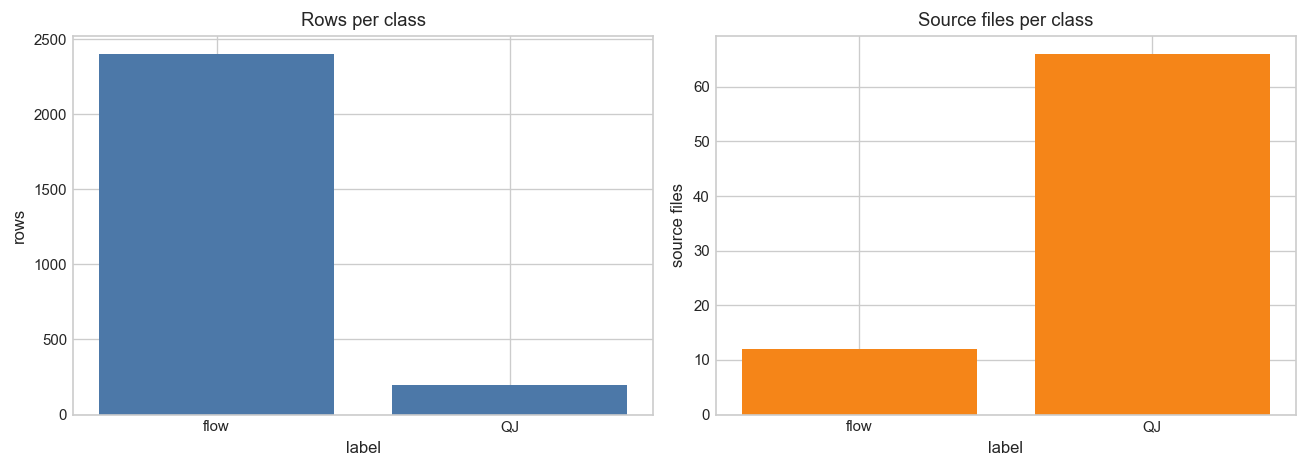

Saved plot: e:\codes\ZZ-BK\outputs\DATA09_feature_importance_from_csv_20260906_002442\class_distribution_20260906_002442.png


In [5]:
# =========================
# Step 2: Class distribution and feature quality checks
# =========================

label_counts = combined['label'].value_counts().rename_axis('label').reset_index(name='rows')
source_counts = combined.groupby('label')['source_file_name'].nunique().rename('source_files').reset_index()
summary_counts = label_counts.merge(source_counts, on='label', how='left')
display(summary_counts)

X_all_numeric = combined.loc[:, feature_cols].apply(pd.to_numeric, errors='coerce')
feature_quality = pd.DataFrame({
    'feature': feature_cols,
    'missing_rate': X_all_numeric.isna().mean().to_numpy(),
    'valid_count': X_all_numeric.notna().sum().to_numpy(),
    'mean': X_all_numeric.mean().to_numpy(),
    'std': X_all_numeric.std().to_numpy(),
    'variance': X_all_numeric.var().to_numpy(),
    'unique_count': X_all_numeric.nunique(dropna=True).to_numpy(),
})
feature_quality['near_zero_variance'] = feature_quality['std'].fillna(0) <= NEAR_ZERO_STD_THRESHOLD

corr_pairs, corr_per_feature = high_correlation_summary(X_all_numeric, CORRELATION_THRESHOLD)
feature_quality = feature_quality.merge(corr_per_feature, on='feature', how='left')
feature_quality['high_corr_partner_count'] = feature_quality['high_corr_partner_count'].fillna(0).astype(int)
feature_quality = feature_quality.sort_values(
    ['missing_rate', 'near_zero_variance', 'high_corr_partner_count', 'variance'],
    ascending=[False, False, False, True],
).reset_index(drop=True)

feature_quality_path = OUTPUT_ROOT / f'feature_quality_{RUN_TIMESTAMP}.csv'
feature_quality.to_csv(feature_quality_path, index=False, encoding='utf-8-sig')
print(f'Saved feature quality table: {feature_quality_path}')
print(f'Near-zero variance features: {int(feature_quality["near_zero_variance"].sum())}')
print(f'Highly correlated feature pairs, |Spearman r| >= {CORRELATION_THRESHOLD}: {len(corr_pairs)}')
display(feature_quality.head(20))

if len(corr_pairs):
    corr_pairs_path = OUTPUT_ROOT / f'high_correlation_pairs_{RUN_TIMESTAMP}.csv'
    corr_pairs.to_csv(corr_pairs_path, index=False, encoding='utf-8-sig')
    print(f'Saved high correlation pairs: {corr_pairs_path}')
    display(corr_pairs.head(20))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(summary_counts['label'], summary_counts['rows'], color='#4c78a8')
axes[0].set_title('Rows per class')
axes[0].set_xlabel('label')
axes[0].set_ylabel('rows')
axes[1].bar(summary_counts['label'], summary_counts['source_files'], color='#f58518')
axes[1].set_title('Source files per class')
axes[1].set_xlabel('label')
axes[1].set_ylabel('source files')
plt.tight_layout()
class_plot_path = OUTPUT_ROOT / f'class_distribution_{RUN_TIMESTAMP}.png'
plt.savefig(class_plot_path)
plt.show()
print(f'Saved plot: {class_plot_path}')


## 6. 6:4 训练测试划分

按 `source_file_name` 分组做 60% 训练、40% 测试划分，避免同一源文件泄漏到两个集合。


In [6]:
# =========================
# Step 3: Train/test split grouped by source file
# =========================

train_idx, test_idx = split_by_source_group(combined, TEST_SIZE, RANDOM_STATE)
combined['split'] = 'train'
combined.loc[test_idx, 'split'] = 'test'

split_summary = (
    combined.groupby(['split', 'label'], dropna=False)
    .agg(rows=('label', 'size'), source_files=('source_file_name', 'nunique'))
    .reset_index()
    .sort_values(['split', 'label'])
)
display(split_summary)

train_sources = set(combined.loc[combined['split'] == 'train', 'source_file_name'].astype(str))
test_sources = set(combined.loc[combined['split'] == 'test', 'source_file_name'].astype(str))
overlap_sources = sorted(train_sources & test_sources)
actual_train_ratio = float((combined['split'] == 'train').mean())
actual_test_ratio = float((combined['split'] == 'test').mean())
print(f'Train rows: {(combined["split"] == "train").sum()} ({actual_train_ratio:.1%}, target 60%)')
print(f'Test rows:  {(combined["split"] == "test").sum()} ({actual_test_ratio:.1%}, target 40%)')
print(f'Overlapped source files between train/test: {len(overlap_sources)}')
if overlap_sources:
    print('[WARN] Overlap exists because row-level fallback split was used.')
    print(overlap_sources[:20])

split_path = OUTPUT_ROOT / f'combined_features_with_split_{RUN_TIMESTAMP}.csv'
combined.to_csv(split_path, index=False, encoding='utf-8-sig')
print(f'Saved split table: {split_path}')


,split,label,rows,source_files
0,test,QJ,81,27
1,test,flow,1000,5
2,train,QJ,117,39
3,train,flow,1400,7


Train rows: 1517 (58.4%, target 60%)
Test rows:  1081 (41.6%, target 40%)
Overlapped source files between train/test: 0
Saved split table: e:\codes\ZZ-BK\outputs\DATA09_feature_importance_from_csv_20260906_002442\combined_features_with_split_20260906_002442.csv


## 7. RandomForest 训练与测试

使用训练集拟合 RandomForest 基线模型，并在 40% 测试集上输出指标、分类报告和混淆矩阵。


{
  "labels": [
    "QJ",
    "flow"
  ],
  "feature_count": 640,
  "train_rows": 1517,
  "test_rows": 1081,
  "accuracy": 1.0,
  "balanced_accuracy": 1.0,
  "macro_f1": 1.0,
  "weighted_f1": 1.0
}
Saved metrics: e:\codes\ZZ-BK\outputs\DATA09_feature_importance_from_csv_20260906_002442\test_metrics_20260906_002442.json


,precision,recall,f1-score,support
QJ,1.0,1.0,1.0,81.0
flow,1.0,1.0,1.0,1000.0
accuracy,1.0,1.0,1.0,1.0
macro avg,1.0,1.0,1.0,1081.0
weighted avg,1.0,1.0,1.0,1081.0


Saved classification report: e:\codes\ZZ-BK\outputs\DATA09_feature_importance_from_csv_20260906_002442\classification_report_20260906_002442.csv


,QJ,flow
QJ,81,0
flow,0,1000


Saved confusion matrix: e:\codes\ZZ-BK\outputs\DATA09_feature_importance_from_csv_20260906_002442\confusion_matrix_20260906_002442.csv


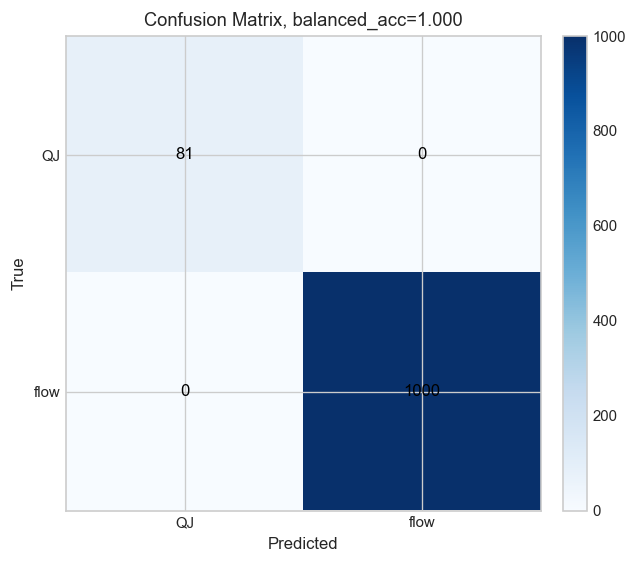

Saved plot: e:\codes\ZZ-BK\outputs\DATA09_feature_importance_from_csv_20260906_002442\confusion_matrix_20260906_002442.png


In [7]:
# =========================
# Step 4: Train RandomForest and evaluate holdout test set
# =========================

X = combined.loc[:, feature_cols].apply(pd.to_numeric, errors='coerce')
y_text = combined['label'].astype(str)
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_text)

train_mask = combined['split'] == 'train'
test_mask = combined['split'] == 'test'

X_train = X.loc[train_mask]
X_test = X.loc[test_mask]
y_train = y[train_mask.to_numpy()]
y_test = y[test_mask.to_numpy()]

model = make_rf_pipeline(RANDOM_STATE)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

metrics = {
    'labels': label_encoder.classes_.tolist(),
    'feature_count': len(feature_cols),
    'train_rows': int(len(X_train)),
    'test_rows': int(len(X_test)),
    'accuracy': float(accuracy_score(y_test, y_pred)),
    'balanced_accuracy': float(balanced_accuracy_score(y_test, y_pred)),
    'macro_f1': float(f1_score(y_test, y_pred, average='macro')),
    'weighted_f1': float(f1_score(y_test, y_pred, average='weighted')),
}
metrics_path = OUTPUT_ROOT / f'test_metrics_{RUN_TIMESTAMP}.json'
metrics_path.write_text(json.dumps(metrics, ensure_ascii=False, indent=2), encoding='utf-8')
print(json.dumps(metrics, ensure_ascii=False, indent=2))
print(f'Saved metrics: {metrics_path}')

report = classification_report(y_test, y_pred, target_names=label_encoder.classes_, output_dict=True, zero_division=0)
report_df = pd.DataFrame(report).T
report_path = OUTPUT_ROOT / f'classification_report_{RUN_TIMESTAMP}.csv'
report_df.to_csv(report_path, encoding='utf-8-sig')
display(report_df)
print(f'Saved classification report: {report_path}')

cm = confusion_matrix(y_test, y_pred, labels=np.arange(len(label_encoder.classes_)))
cm_df = pd.DataFrame(cm, index=label_encoder.classes_, columns=label_encoder.classes_)
cm_path = OUTPUT_ROOT / f'confusion_matrix_{RUN_TIMESTAMP}.csv'
cm_df.to_csv(cm_path, encoding='utf-8-sig')
display(cm_df)
print(f'Saved confusion matrix: {cm_path}')

fig, ax = plt.subplots(figsize=(5.5, 4.8))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(np.arange(len(label_encoder.classes_)), labels=label_encoder.classes_)
ax.set_yticks(np.arange(len(label_encoder.classes_)), labels=label_encoder.classes_)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title(f'Confusion Matrix, balanced_acc={metrics["balanced_accuracy"]:.3f}')
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, int(cm[i, j]), ha='center', va='center', color='black')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
cm_plot_path = OUTPUT_ROOT / f'confusion_matrix_{RUN_TIMESTAMP}.png'
plt.savefig(cm_plot_path)
plt.show()
print(f'Saved plot: {cm_plot_path}')


## 8. 特征重要性排序

重要性排序的科学性风险与修正：

- RandomForest impurity importance 对连续变量、取值更多的变量以及相关特征存在系统性偏好，不能单独作为特征贡献结论。
- 使用测试集 permutation importance 再参与排序，会把独立测试集用于模型解释和筛选，削弱 6:4 holdout 的独立验证意义。
- 单次随机划分和单个随机种子的排序缺少稳定性估计，Top 特征可能只是抽样或模型随机性的结果。
- 高相关特征会分摊或替代彼此的重要性，单个特征排名不等同于物理机制或因果贡献。
- 当类别、来源文件或窗口数量不均衡时，必须优先看 balanced accuracy、macro F1、分组划分和分组交叉验证结果。

因此下面的主排序使用训练集内部的分组交叉验证 permutation importance，并报告 fold 均值、标准差、正向 fold 占比和多随机种子 RF impurity 稳定性。独立测试集 permutation importance 只作为审计指标，不参与主排序。


In [ ]:
# =========================
# Step 5: Feature importance ranking with train-only CV evidence
# =========================

rf = model.named_steps['rf']
rf_importance = pd.DataFrame({
    'feature': feature_cols,
    'rf_importance_holdout_model': rf.feature_importances_,
})

print('Estimating RF impurity-importance stability across random seeds on the training set...')
seed_importances = []
for seed in RF_STABILITY_SEEDS:
    seed_model = make_rf_pipeline(seed)
    seed_model.fit(X_train, y_train)
    seed_importances.append(seed_model.named_steps['rf'].feature_importances_)
seed_importances = np.vstack(seed_importances)
rf_stability = pd.DataFrame({
    'feature': feature_cols,
    'rf_importance_seed_mean': seed_importances.mean(axis=0),
    'rf_importance_seed_std': seed_importances.std(axis=0, ddof=1) if len(RF_STABILITY_SEEDS) > 1 else np.zeros(len(feature_cols)),
})

print('Running train-only cross-validated permutation importance...')
cv_splitter, cv_groups, cv_splits, cv_name = build_cv_splitter(combined, train_mask, CV_FOLDS, RANDOM_STATE)
print(f'CV splitter: {cv_name}, folds={cv_splits}')
cv_perm_rows = []
train_positions = np.arange(len(X_train))
if cv_groups is None:
    split_iter = cv_splitter.split(X_train, y_train)
else:
    split_iter = cv_splitter.split(X_train, y_train, groups=cv_groups)

for fold, (fold_train_pos, fold_valid_pos) in enumerate(split_iter, start=1):
    fold_model = make_rf_pipeline(RANDOM_STATE + fold)
    fold_model.fit(X_train.iloc[fold_train_pos], y_train[fold_train_pos])
    fold_pred = fold_model.predict(X_train.iloc[fold_valid_pos])
    fold_score = balanced_accuracy_score(y_train[fold_valid_pos], fold_pred)
    perm = permutation_importance(
        fold_model,
        X_train.iloc[fold_valid_pos],
        y_train[fold_valid_pos],
        n_repeats=PERMUTATION_REPEATS,
        random_state=RANDOM_STATE + fold,
        scoring='balanced_accuracy',
        n_jobs=-1,
    )
    fold_df = pd.DataFrame({
        'fold': fold,
        'feature': feature_cols,
        'cv_permutation_importance': perm.importances_mean,
        'cv_permutation_importance_std_within_fold': perm.importances_std,
        'fold_balanced_accuracy': fold_score,
        'fold_valid_rows': len(fold_valid_pos),
    })
    cv_perm_rows.append(fold_df)

cv_perm_long = pd.concat(cv_perm_rows, ignore_index=True)
cv_perm_long_path = OUTPUT_ROOT / f'cv_permutation_importance_long_{RUN_TIMESTAMP}.csv'
cv_perm_long.to_csv(cv_perm_long_path, index=False, encoding='utf-8-sig')
print(f'Saved CV permutation long table: {cv_perm_long_path}')

cv_perm = (
    cv_perm_long.groupby('feature')
    .agg(
        cv_permutation_importance_mean=('cv_permutation_importance', 'mean'),
        cv_permutation_importance_std=('cv_permutation_importance', 'std'),
        cv_permutation_positive_fold_fraction=('cv_permutation_importance', lambda s: float((s > 0).mean())),
        cv_fold_balanced_accuracy_mean=('fold_balanced_accuracy', 'mean'),
    )
    .reset_index()
)
cv_perm['cv_permutation_importance_std'] = cv_perm['cv_permutation_importance_std'].fillna(0)

if RUN_PERMUTATION_IMPORTANCE:
    print('Running holdout-test permutation importance for audit only...')
    test_perm = permutation_importance(
        model, X_test, y_test,
        n_repeats=PERMUTATION_REPEATS,
        random_state=RANDOM_STATE,
        scoring='balanced_accuracy',
        n_jobs=-1,
    )
    test_perm_df = pd.DataFrame({
        'feature': feature_cols,
        'test_permutation_importance_mean_audit_only': test_perm.importances_mean,
        'test_permutation_importance_std_audit_only': test_perm.importances_std,
    })
else:
    test_perm_df = pd.DataFrame({'feature': feature_cols})

importance = (
    cv_perm
    .merge(rf_importance, on='feature', how='left')
    .merge(rf_stability, on='feature', how='left')
    .merge(feature_quality[['feature', 'missing_rate', 'near_zero_variance', 'high_corr_partner_count']], on='feature', how='left')
    .merge(test_perm_df, on='feature', how='left')
)
importance['rank_cv_permutation'] = importance['cv_permutation_importance_mean'].rank(ascending=False, method='min').astype(int)
importance['rank_rf_stability'] = importance['rf_importance_seed_mean'].rank(ascending=False, method='min').astype(int)
importance['stability_adjusted_score'] = importance['cv_permutation_importance_mean'] - importance['cv_permutation_importance_std'].fillna(0)
importance['rank_stability_adjusted'] = importance['stability_adjusted_score'].rank(ascending=False, method='min').astype(int)
importance = importance.sort_values(
    ['rank_stability_adjusted', 'rank_cv_permutation', 'rank_rf_stability', 'feature']
).reset_index(drop=True)
importance.insert(0, 'importance_rank', np.arange(1, len(importance) + 1))

importance_path = OUTPUT_ROOT / f'feature_importance_{RUN_TIMESTAMP}.csv'
importance.to_csv(importance_path, index=False, encoding='utf-8-sig')
print(f'Saved feature importance: {importance_path}')
display(importance.head(TOP_N))

fig, ax = plt.subplots(figsize=(9, max(5, TOP_N * 0.24)))
plot_df = importance.head(TOP_N).iloc[::-1]
ax.barh(plot_df['feature'], plot_df['cv_permutation_importance_mean'], color='#4c78a8', xerr=plot_df['cv_permutation_importance_std'])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Train-CV permutation importance, balanced accuracy drop')
ax.set_title(f'Top {TOP_N} Feature Importance, train-CV stability adjusted')
plt.tight_layout()
importance_plot_path = OUTPUT_ROOT / f'feature_importance_top{TOP_N}_{RUN_TIMESTAMP}.png'
plt.savefig(importance_plot_path)
plt.show()
print(f'Saved plot: {importance_plot_path}')


Estimating RF impurity-importance stability across random seeds on the training set...
Running train-only cross-validated permutation importance...
CV splitter: StratifiedGroupKFold, folds=5
Saved CV permutation long table: e:\codes\ZZ-BK\outputs\DATA09_feature_importance_from_csv_20260906_002442\cv_permutation_importance_long_20260906_002442.csv
Running holdout-test permutation importance for audit only...


## 9. 错误样本与 Top 特征分布

列出测试集中分类错误的样本，并绘制高重要性特征在各类别中的分布。


Misclassified samples: 0
Saved misclassified samples: e:\codes\ZZ-BK\outputs\DATA09_feature_importance_from_csv_20260904_163550\misclassified_samples_20260904_163550.csv


,label,source_file_name,sample_id,feature_csv_name,pred_label,correct


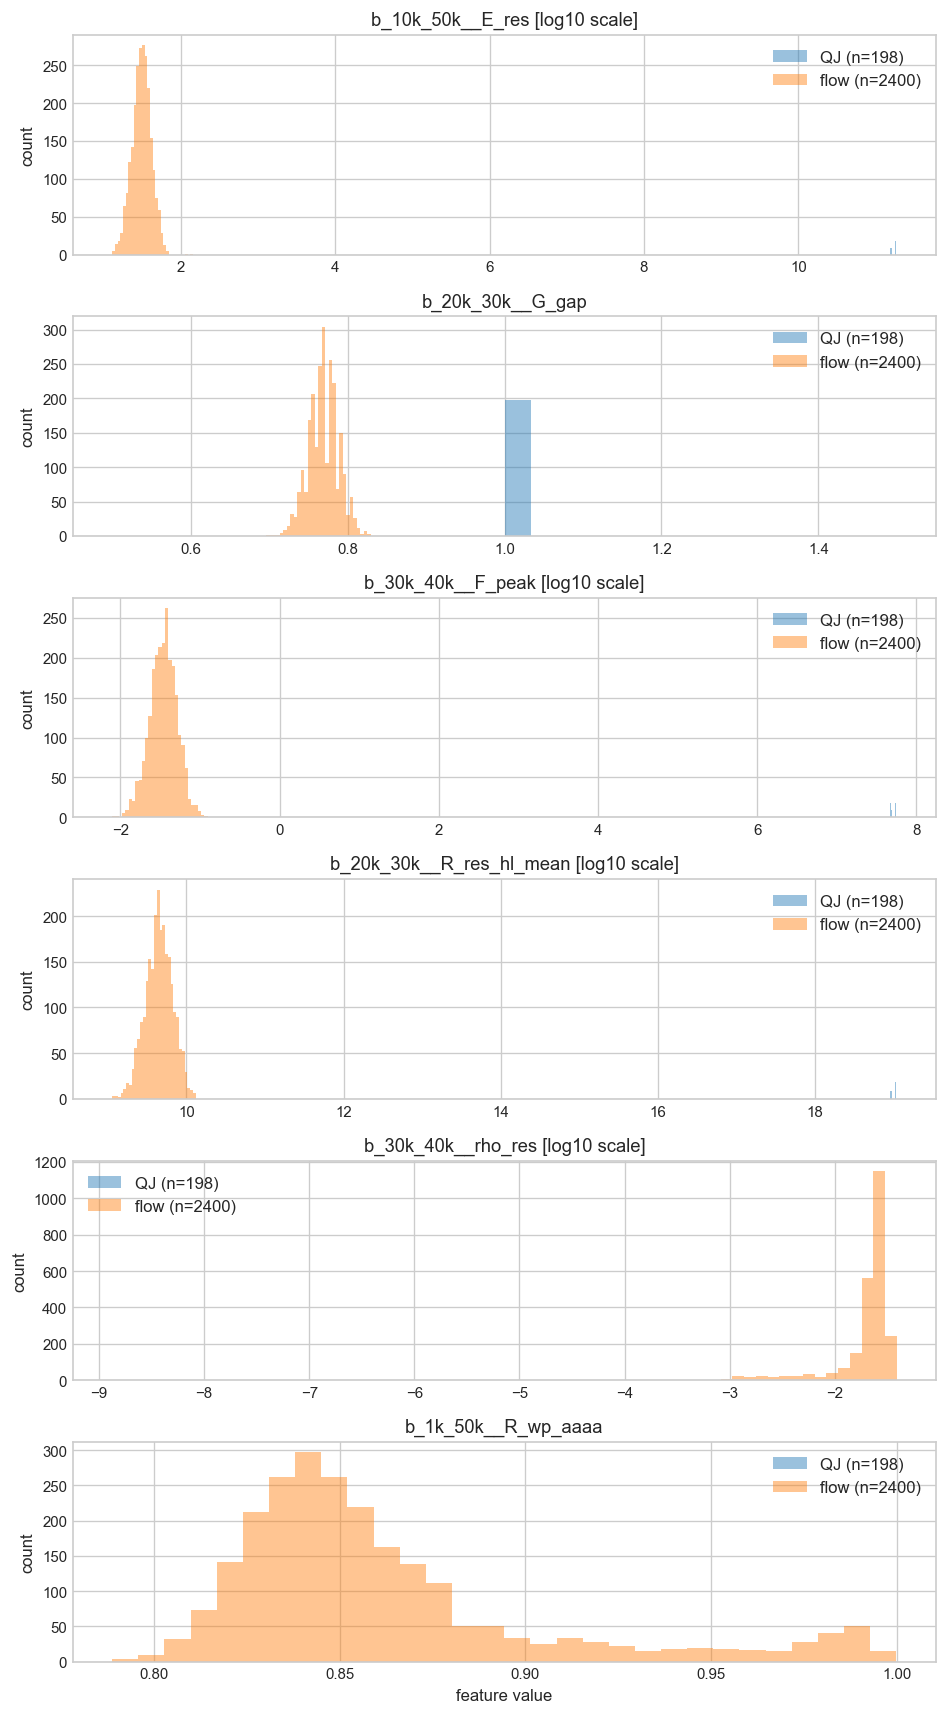

Saved plot: e:\codes\ZZ-BK\outputs\DATA09_feature_importance_from_csv_20260904_163550\top_feature_distributions_20260904_163550.png


In [ ]:
# =========================
# Step 6: Misclassified samples and top feature distributions
# =========================

test_rows = combined.loc[test_mask, ['label', 'source_file_name', 'sample_id', 'feature_csv_name']].copy()
test_rows['pred_label'] = label_encoder.inverse_transform(y_pred)
test_rows['correct'] = test_rows['label'].astype(str) == test_rows['pred_label'].astype(str)
misclassified = test_rows.loc[~test_rows['correct']].copy()
misclassified_path = OUTPUT_ROOT / f'misclassified_samples_{RUN_TIMESTAMP}.csv'
misclassified.to_csv(misclassified_path, index=False, encoding='utf-8-sig')
print(f'Misclassified samples: {len(misclassified)}')
print(f'Saved misclassified samples: {misclassified_path}')
display(misclassified.head(50))

plot_features = importance.head(min(6, len(importance)))['feature'].tolist()
if plot_features:
    n = len(plot_features)
    fig, axes = plt.subplots(n, 1, figsize=(8, max(3, 2.4 * n)), sharex=False)
    if n == 1:
        axes = [axes]
    for ax, feat in zip(axes, plot_features):
        all_values = pd.to_numeric(combined[feat], errors='coerce').replace([np.inf, -np.inf], np.nan).dropna()
        if all_values.empty:
            ax.text(0.5, 0.5, 'all values are NaN', ha='center', va='center', transform=ax.transAxes)
            ax.set_title(feat)
            continue

        positive = all_values[all_values > 0]
        use_log = False
        if len(positive) == len(all_values):
            q01 = positive.quantile(0.01)
            q99 = positive.quantile(0.99)
            use_log = bool(q01 > 0 and q99 / q01 > 1e4)

        plotted_any = False
        for label in label_encoder.classes_:
            raw = pd.to_numeric(
                combined.loc[combined['label'].astype(str) == label, feat],
                errors='coerce',
            ).replace([np.inf, -np.inf], np.nan).dropna()
            if raw.empty:
                continue
            values = np.log10(raw.to_numpy()) if use_log else raw.to_numpy()
            ax.hist(values, bins=30, alpha=0.45, density=False, label=f'{label} (n={len(raw)})')
            plotted_any = True

        if not plotted_any:
            ax.text(0.5, 0.5, 'no finite values to plot', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(feat + (' [log10 scale]' if use_log else ''))
        ax.set_ylabel('count')
        ax.legend(loc='best')
    axes[-1].set_xlabel('feature value')
    plt.tight_layout()
    dist_plot_path = OUTPUT_ROOT / f'top_feature_distributions_{RUN_TIMESTAMP}.png'
    plt.savefig(dist_plot_path)
    plt.show()
    print(f'Saved plot: {dist_plot_path}')


## 10. 输出文件清单

列出本次运行在输出目录中生成的 CSV、JSON 和 PNG 结果文件。


In [ ]:
# =========================
# Step 7: Output artifact list
# =========================

artifacts = sorted(OUTPUT_ROOT.glob('*'))
print(f'Artifacts in {OUTPUT_ROOT}:')
for path in artifacts:
    print(' ', path.name)


Artifacts in e:\codes\ZZ-BK\outputs\DATA09_feature_importance_from_csv_20260904_163550:
  class_distribution_20260904_163550.png
  classification_report_20260904_163550.csv
  combined_features_20260904_163550.csv
  combined_features_with_split_20260904_163550.csv
  confusion_matrix_20260904_163550.csv
  confusion_matrix_20260904_163550.png
  feature_importance_20260904_163550.csv
  feature_importance_top30_20260904_163550.png
  feature_quality_20260904_163550.csv
  misclassified_samples_20260904_163550.csv
  test_metrics_20260904_163550.json
  top_feature_distributions_20260904_163550.png
